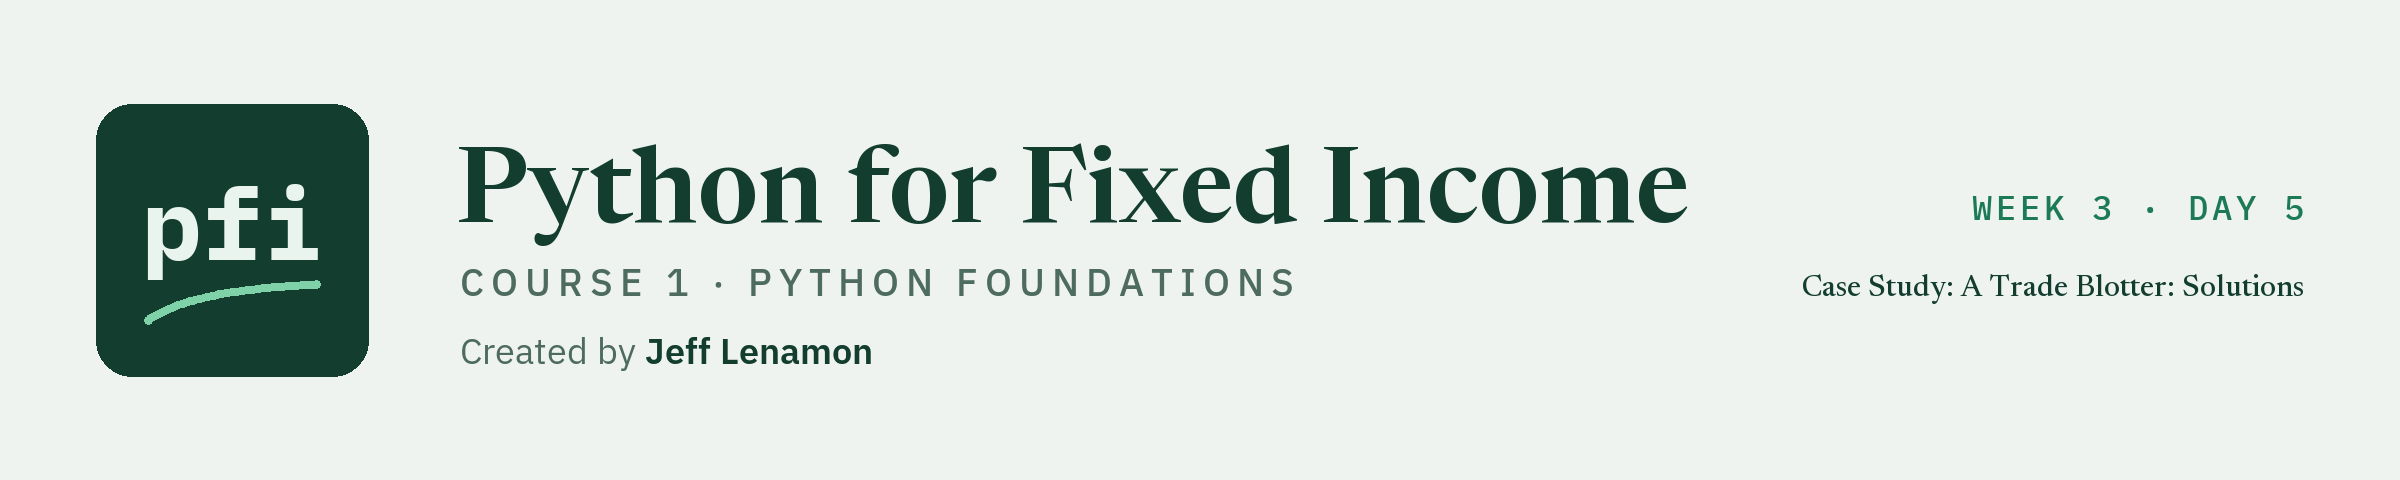

# Case Study: A Trade Blotter - Solutions

Week 3. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week3/day5/15_case_study_trade_blotter_solutions.ipynb)

## Exercises

The exercises use the same blotter and ask about columns and groups the lesson did not examine: the principal, dollars by hour, the two grades, and the second most traded bond. All names are invented. Every answer describes the data, and none is a view on a bond, a counterparty, or a desk.

Replace each `...` with your own code, then run the check cell. Exercise 5 asks for a function. Print the numbers you rely on, say the unit, and where an exercise asks for a chart, give it a title and axis labels with units. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It imports the libraries, defines `check`, a small function that marks your answers, and loads fresh copies of `blotter`, `holdings`, and `ratings`. It also builds `trades`, the blotter joined to the holdings and the ratings. It prints the two shapes, (374, 12) and (374, 17).

In [1]:
import os

import matplotlib.pyplot as plt
import pandas as pd


def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    # ... is the placeholder, and None is what a function returns before its body is written
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
        return
    if isinstance(expected, float):
        # single numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 0.000001
    else:
        correct = answer == expected
    if correct:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# fresh copies of the three files. In Colab they are read from GitHub.
if os.path.exists('../../../data/trade_blotter.csv'):
    data_folder = '../../../data/'
else:
    data_folder = 'https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/'

blotter = pd.read_csv(data_folder + 'trade_blotter.csv', parse_dates=['trade_date', 'settle_date'])
holdings = pd.read_csv(data_folder + 'holdings.csv')
ratings = pd.read_csv(data_folder + 'ratings.csv')

# the joined table of the lesson: every trade with its issuer, sector, rating, month-end price, and grade
bond_details = holdings[['cusip', 'issuer', 'sector', 'rating', 'price']].rename(columns={'price': 'month_end_price'})
trades = pd.merge(blotter, bond_details, on='cusip', how='left', validate='many_to_one')
trades = pd.merge(trades, ratings[['rating', 'grade']], on='rating', how='left', validate='many_to_one')

print(blotter.shape, trades.shape)

(374, 12) (374, 17)


### Exercise 1

Q. Apply the IQR rule to the `principal` column of `blotter`. How many trades are above the upper limit, and what is the largest principal? Store the answers in **ex1_flagged** and **ex1_largest**. Look at the flagged rows and say whether they are errors.

In [2]:
# the quartiles, the IQR, and the upper limit
q1 = blotter['principal'].quantile(0.25)
q3 = blotter['principal'].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + 1.5 * iqr
print('First quartile:', round(q1, 2), ' third quartile:', round(q3, 2), ' upper limit:', round(upper_limit, 2), 'dollars')

# the trades above the limit, largest first
flagged = blotter[blotter['principal'] > upper_limit].sort_values('principal', ascending=False)

ex1_flagged = len(flagged)
ex1_largest = blotter['principal'].max()

print('Trades flagged:', ex1_flagged)
print('Largest principal:', ex1_largest, 'dollars')
print(flagged[['trade_id', 'ticker', 'side', 'quantity', 'price', 'principal']])

First quartile: 105323.25  third quartile: 392736.0  upper limit: 823855.12 dollars
Trades flagged: 10
Largest principal: 5335100.0 dollars
    trade_id ticker  side  quantity    price  principal
159    T0160   CLAE  SELL   5000000  106.702  5335100.0
50     T0051   RULL  SELL   4000000  103.059  4122360.0
236    T0237   PLER   BUY   3000000   98.307  2949210.0
366    T0367   VRAN  SELL   3000000   92.203  2766090.0
150    T0151   DRAH   BUY   2500000   94.101  2352525.0
137    T0138   THAN  SELL   2000000   94.181  1883620.0
118    T0119   GRON   BUY    750000  116.857   876427.5
187    T0188   SKEY   BUY    750000  116.080   870600.0
190    T0191   HESR   BUY    750000  113.677   852577.5
331    T0332   VYRE   BUY    760000  109.973   835794.8


* The upper limit is 823,855.12 dollars of principal, and 10 trades are above it. The largest is 5,335,100.0 dollars, the 5,000,000 sale of the lesson.
* The lesson's rule on `quantity` flagged 6 trades. On `principal` it flags the same six trades and four more, with principals from 835,794.8 to 876,427.5 dollars.
* The four have quantities of 750,000 or 760,000 dollars of face, inside the lesson's limit of 850,000, at prices from 109.973 to 116.857. Their principals tie out to quantity times price. None of the ten is an error.
* The two columns measure nearly the same thing and the rule draws its line in a slightly different place on each. A flag is a reason to read the row, and the rows here are ordinary trades at high prices.

In [3]:
check('Exercise 1 trades flagged', ex1_flagged, 10)
check('Exercise 1 largest principal', ex1_largest, 5335100.0)

Exercise 1 trades flagged: correct
Exercise 1 largest principal: correct


### Exercise 2

Q. The lesson counted trades by hour and found the most in the hour from 10:00. Now add up the **principal** by hour, in millions of dollars. Which hour has the most principal, and how much, rounded to 2 decimal places? Store the answers in **ex2_hour** and **ex2_millions**. Draw the principal by hour as a bar chart.

hour
8      5.51
9     18.38
10    20.44
11    21.29
12     5.54
13     5.14
14    20.50
15     9.69
16    10.98
Name: principal, dtype: float64
Hour with the most principal: 11 with 21.29 million dollars


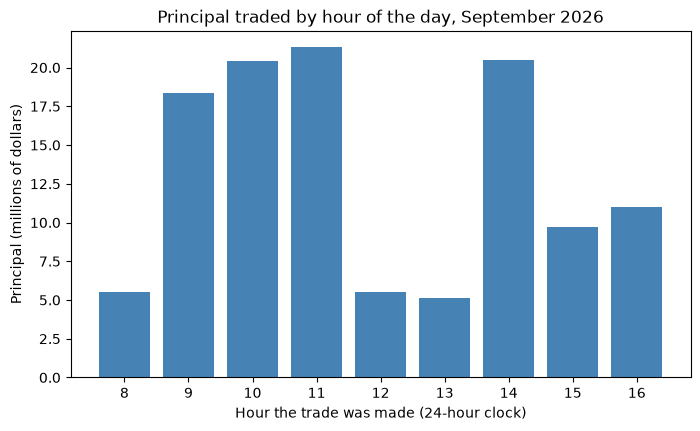

In [4]:
# the hour of each trade, from the time held as text
trades['hour'] = pd.to_datetime(trades['trade_time'], format='%H:%M').dt.hour

# the principal of each hour, in millions of dollars
principal_by_hour = trades.groupby('hour')['principal'].sum() / 1_000_000
print(principal_by_hour.round(2))

# idxmax() returns the row label, here the hour, of the largest value
ex2_hour = principal_by_hour.idxmax()
ex2_millions = round(principal_by_hour.max(), 2)

print('Hour with the most principal:', ex2_hour, 'with', ex2_millions, 'million dollars')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(principal_by_hour.index, principal_by_hour.values, color='steelblue')
ax.set_xticks(principal_by_hour.index)
ax.set_title('Principal traded by hour of the day, September 2026')
ax.set_xlabel('Hour the trade was made (24-hour clock)')
ax.set_ylabel('Principal (millions of dollars)')
plt.show()

* The hour from 11:00 has the most principal, 21.29 million dollars. By number of trades the lesson's busiest hour was 10, which has 20.44 million.
* The hour from 14:00 has 20.5 million dollars and the hour from 15:00 has 9.69 million. By count the lesson had those two hours close together, at 51 trades and 44.
* A count by hour and a sum by hour rank the hours differently, because trade sizes differ. It is the count against dollars point of the counterparty table, on another column.

In [5]:
check('Exercise 2 hour', ex2_hour, 11)
check('Exercise 2 millions', ex2_millions, 21.29)

Exercise 2 hour: correct
Exercise 2 millions: correct


### Exercise 3

Q. What was the net principal traded, buys less sells, in each grade, in millions of dollars rounded to 2 decimal places? Store the answers in **ex3_ig** and **ex3_hy**. Check that the two add up to the net of the whole blotter. Draw the two nets as horizontal bars with a line at zero.

side                BUY   SELL   net
grade                               
High Yield        14.22   9.96  4.27
Investment Grade  42.33  50.96 -8.63
Investment Grade net: -8.63 million dollars
High Yield net: 4.27 million dollars
Sum of the two: -4.36 million dollars


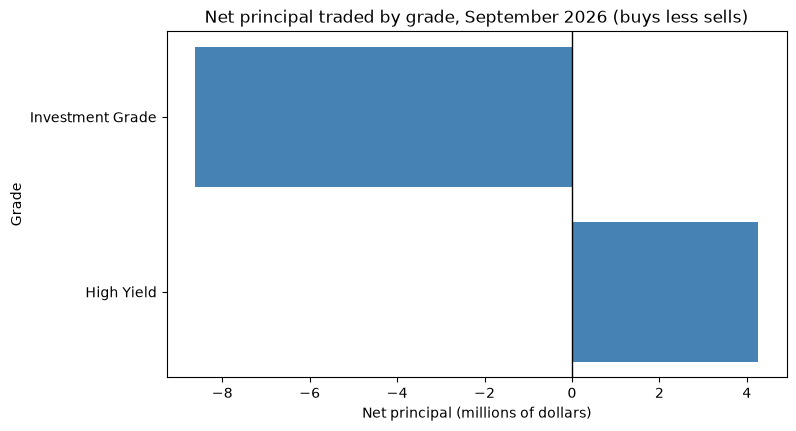

In [6]:
# grades down the side, the two sides across the top, the sum of principal in millions of dollars
by_grade = pd.pivot_table(trades, values='principal', index='grade', columns='side', aggfunc='sum') / 1_000_000
by_grade['net'] = by_grade['BUY'] - by_grade['SELL']
print(by_grade.round(2))

ex3_ig = round(by_grade.loc['Investment Grade', 'net'], 2)
ex3_hy = round(by_grade.loc['High Yield', 'net'], 2)

print('Investment Grade net:', ex3_ig, 'million dollars')
print('High Yield net:', ex3_hy, 'million dollars')
print('Sum of the two:', round(by_grade['net'].sum(), 2), 'million dollars')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(by_grade.index, by_grade['net'], color='steelblue')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Net principal traded by grade, September 2026 (buys less sells)')
ax.set_xlabel('Net principal (millions of dollars)')
ax.set_ylabel('Grade')
plt.show()

* The desk was a net seller of Investment Grade bonds, -8.63 million dollars, and a net buyer of High Yield bonds, 4.27 million.
* The two add up to -4.36 million, the net of the whole blotter in the lesson.
* In Investment Grade the desk bought 42.33 million and sold 50.96 million. In High Yield it bought 14.22 million and sold 9.96 million.
* The whole-blotter net of -4.36 million is the sum of two figures with opposite signs. The bars on either side of the zero line show that at a glance.

In [7]:
check('Exercise 3 Investment Grade net', ex3_ig, -8.63)
check('Exercise 3 High Yield net', ex3_hy, 4.27)

Exercise 3 Investment Grade net: correct
Exercise 3 High Yield net: correct


### Exercise 4

Q. Which bond traded second most often? Store its cusip in **ex4_cusip**. For that bond, work out the simple average traded price and the volume-weighted average traded price, each rounded to 3 decimal places, and store them in **ex4_simple** and **ex4_weighted**. Print its month-end price beside them.

In [8]:
# count the trades in each bond, most traded first. The second row is position 1.
trades_per_bond = trades['cusip'].value_counts()
print(trades_per_bond.head(3))
ex4_cusip = trades_per_bond.index[1]

# the trades in that bond
second = trades[trades['cusip'] == ex4_cusip]

# the simple average, and the average weighted by the face traded
ex4_simple = round(second['price'].mean(), 3)
ex4_weighted = round((second['price'] * second['quantity']).sum() / second['quantity'].sum(), 3)

month_end = second['month_end_price'].iloc[0]

print('Bond:', ex4_cusip, second['ticker'].iloc[0], second['issuer'].iloc[0], ' trades:', len(second))
print('Simple average traded price:', ex4_simple)
print('Volume-weighted average traded price:', ex4_weighted)
print('Month-end price:', month_end)
print('Simple average less month-end price:', round(ex4_simple - month_end, 3), 'points')
print('Simple average less volume-weighted average:', round(ex4_simple - ex4_weighted, 3), 'points')

cusip
99075XAE9    20
99114KAB6    16
99007HAA5    14
Name: count, dtype: int64
Bond: 99114KAB6 LORE Lorvane Systems  trades: 16
Simple average traded price: 104.706
Volume-weighted average traded price: 104.687
Month-end price: 105.239
Simple average less month-end price: -0.533 points
Simple average less volume-weighted average: 0.019 points


* The second most traded bond is `99114KAB6`, of Lorvane Systems, ticker LORE, with 16 trades.
* Its simple average traded price is 104.706 and its volume-weighted average is 104.687. The month-end price is 105.239, so the simple average is 0.533 points below it.
* `value_counts()` sorts from most to fewest, so the second most traded bond is at position 1 of its index. Position 0 is the lesson's bond.
* The two averages differ by 0.019 points. As in the lesson, the figures describe the prices the bond traded at and are not a view on it.

In [9]:
check('Exercise 4 cusip', ex4_cusip, '99114KAB6')
check('Exercise 4 simple average', ex4_simple, 104.706)
check('Exercise 4 weighted average', ex4_weighted, 104.687)

Exercise 4 cusip: correct
Exercise 4 simple average: correct
Exercise 4 weighted average: correct


### Exercise 5

The lesson worked out the volume-weighted average traded price of one bond, and exercise 4 did it again for another. A third bond should not mean a third copy of the code.

Q. Write a function that takes a table of trades and a cusip and returns the volume-weighted average traded price of that bond, rounded to 3 decimal places. If the table has no trade in that cusip, the function stops with an `assert` and a message. Then call it for `99075XAE9`, the lesson's bond, and for `99114KAB6`, the bond of exercise 4. Store the answers in **ex5_first** and **ex5_second**.

In [10]:
def weighted_average_price(table, cusip):
    """Return the volume-weighted average traded price of one bond, rounded to 3 decimal places."""
    # the trades in this bond
    bond_trades = table[table['cusip'] == cusip]

    # no trades means no average, so stop with a message and do not return a number
    assert len(bond_trades) > 0, f'no trades in {cusip}'

    # each price counts in proportion to the face traded at it
    weighted = (bond_trades['price'] * bond_trades['quantity']).sum() / bond_trades['quantity'].sum()

    # float() turns the NumPy number into a plain one
    return round(float(weighted), 3)


ex5_first = weighted_average_price(trades, '99075XAE9')
ex5_second = weighted_average_price(trades, '99114KAB6')

print(f'99075XAE9: {ex5_first:,.3f}')
print(f'99114KAB6: {ex5_second:,.3f}')

# how many bonds could the function be called for?
print(f'Bonds traded: {trades["cusip"].nunique():,}')

99075XAE9: 99.742
99114KAB6: 104.687
Bonds traded: 128


* 99.742 for `99075XAE9`, the figure of section 5.3, and 104.687 for `99114KAB6`, the figure of exercise 4.
* The filter, the weighting, and the rounding are written once. Any of the 128 bonds that traded is now one call.
* The `assert` covers the case the arithmetic cannot. With no trades the sum of the quantities is zero, and zero divided by zero gives `NaN` and a warning, not an error. The function stops with `no trades in` and the cusip, and never hands back a `NaN` that could travel into a report.
* The prices describe what the bond traded at in the blotter. They are not a view on it.

In [11]:
check('Exercise 5 99075XAE9', ex5_first, 99.742)
check('Exercise 5 99114KAB6', ex5_second, 104.687)

# a cusip with no trades should stop the function. try and except, from week 1, catch the error so the check can report it.
if ex5_first is not None:
    try:
        weighted_average_price(trades, 'NOTACUSIP')
        stopped = False
    except AssertionError as error:
        stopped = True
        print('Stopped with the message:', error)
    check('Exercise 5 the assert stops a cusip with no trades', stopped, True)

Exercise 5 99075XAE9: correct
Exercise 5 99114KAB6: correct
Stopped with the message: no trades in NOTACUSIP
Exercise 5 the assert stops a cusip with no trades: correct


### Exercise 6: AI check

You ask an AI assistant for the net dollars the desk bought in each sector in September, and the net for the whole blotter. It gives you the code below. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

Q. Read the code before you run it. What should the Financials figure be, and what should the total be? The lesson worked both out in section 4.1. Then run the code. Does the answer agree with you?

* The lesson's net for Financials is -7.04 million dollars and the net of the whole blotter is -4.36 million. The original code reported 16.13 million for Financials and 117.47 million for the total, with no error and no warning.
* The bug was the line `trades.groupby('sector')['principal'].sum()`. It adds up the principal of every trade, buys and sells together. `principal` is never negative in the file: the direction of a trade is in the `side` column, and the code never read it. What it worked out is the total traded, buys plus sells, under the name net.
* Three things give it away. Every one of the ten figures is above zero, and a desk that sold more than it bought overall cannot be a net buyer in every sector. The total, 117.47, is the lesson's total traded. And the Financials figure has the wrong sign against the lesson's -7.04.
* The fix is to split the principal by side and subtract: buys less sells.

In [12]:
# dollars bought and sold in each sector, in millions
by_sector = pd.pivot_table(trades, values='principal', index='sector', columns='side', aggfunc='sum') / 1_000_000

# net is buys less sells
net_by_sector = by_sector['BUY'] - by_sector['SELL']
print(net_by_sector.round(2))

ex6_financials = round(net_by_sector.loc['Financials'], 2)
ex6_total = round(net_by_sector.sum(), 2)

print('Net bought in Financials:', ex6_financials, 'million dollars')
print('Net bought in the whole blotter:', ex6_total, 'million dollars')

sector
Consumer         -6.05
Energy            6.32
Financials       -7.04
Health Care       2.06
Industrials       3.41
Materials         0.35
Technology       -3.35
Telecom          -2.74
Transportation    0.59
Utilities         2.09
dtype: float64
Net bought in Financials: -7.04 million dollars
Net bought in the whole blotter: -4.36 million dollars


In [13]:
check('Exercise 6 Financials net', ex6_financials, -7.04)
check('Exercise 6 total net', ex6_total, -4.36)

Exercise 6 Financials net: correct
Exercise 6 total net: correct
